In [ ]:
from pathlib import Path
import json
import pandas as pd

# Works when the notebook runs from the project root or notebooks/.
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

rows = []

for path in sorted((root / "results" / "ex3").rglob("*.json")):
    saved = json.loads(path.read_text())
    config = saved["config"]
    result = saved["result"]
    extra = config.get("extra", {})

    rows.append({
        "experiment": path.parent.name,
        "layers": str(config["hidden_layers"]),
        "optimizer": config["optimizer_method"],
        "learning_rate": config["learning_rate"],
        "epochs": config["epochs"],
        "split": extra.get("split", "sequential"),
        "extra_data": bool(extra.get("extra_dataset")),
        "oversampling": extra.get("oversample", False),
        "accuracy_percent": 100 * result["accuracy"],
        "final_valid_loss": result["valid_loss"][-1],
        "seconds": result["total_seconds"],
    })

results = pd.DataFrame(rows).sort_values(
    "accuracy_percent", ascending=False
)

results = pd.DataFrame(rows).sort_values(
    "accuracy_percent", ascending=False
)

results = results[results["experiment"] != "best_saved"]

display(results.round(4))

,experiment,layers,optimizer,learning_rate,epochs,split,extra_data,oversampling,accuracy_percent,final_valid_loss,seconds
3,adam_h256-128_extra_oversampled_60epochs,"[256, 128]",adam,0.0005,60,stratified,True,True,97.5865,0.0218,112.6899
11,best_saved,"[256, 128]",adam,0.0005,60,stratified,True,True,97.5865,0.0218,110.8516
2,adam_h256-128_extra_data_60epochs,"[256, 128]",adam,0.0005,60,stratified,True,False,97.4913,0.0217,90.0549
1,adam_h256-128_extra_data,"[256, 128]",adam,0.0005,70,stratified,True,False,97.2055,0.0224,98.3680
5,adam_h256_extra_data,[256],adam,0.0005,70,stratified,True,False,97.1102,0.0252,88.9842
4,adam_h256_70epochs,[256],adam,0.0005,70,stratified,False,False,96.7291,0.0312,48.6754
8,adam_lr0005_h128-64_70epochs,"[128, 64]",adam,0.0005,70,stratified,False,False,96.5703,0.0289,20.4102
0,adam_h128-64_70epochs,"[128, 64]",adam,0.0010,70,stratified,False,False,96.5068,0.0298,20.1984
9,adam_oversampled,"[128, 64]",adam,0.0005,70,stratified,False,True,96.1575,0.0310,28.2936
7,adam_h64-64_70epochs,"[64, 64]",adam,0.0010,70,stratified,False,False,95.6812,0.0350,11.8233


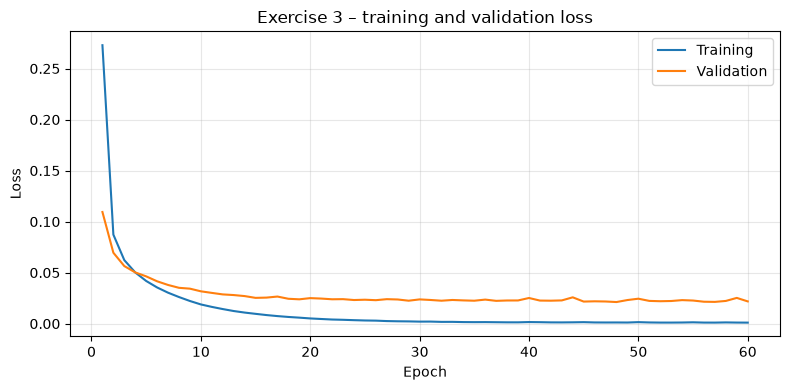

In [2]:
import matplotlib.pyplot as plt

best_path = next(
    (root / "results" / "ex3" / "best_saved").glob("*.json")
)
saved = json.loads(best_path.read_text())
best_result = saved["result"]

epochs = range(1, len(best_result["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, best_result["train_loss"], label="Training")
plt.plot(epochs, best_result["valid_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exercise 3 – training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Text(83.33333333333333, 0.5, 'Actual digit')

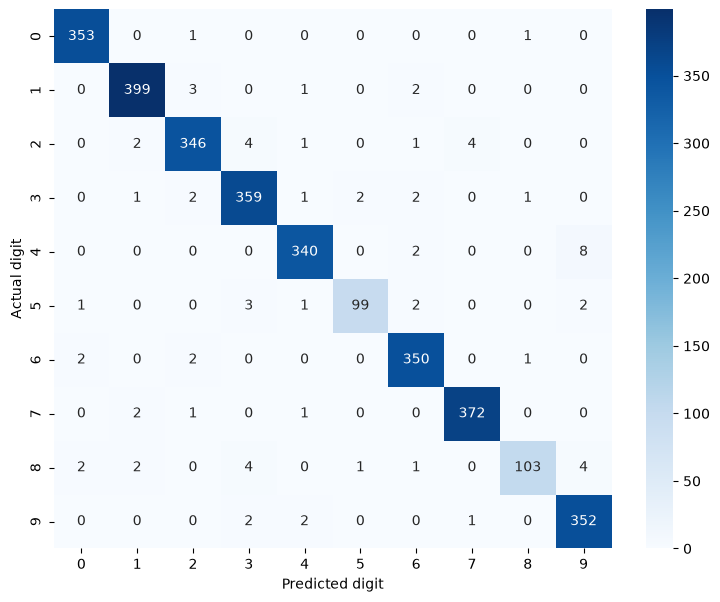

In [5]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(
    best_result["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10),
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")

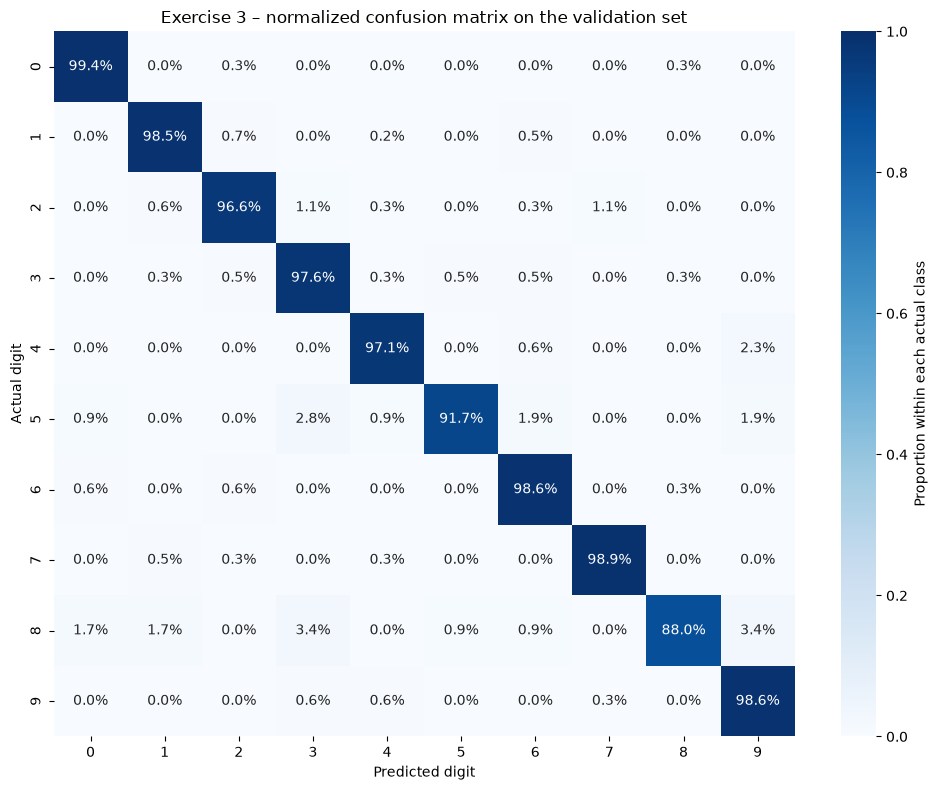

In [6]:
import numpy as np

cm = np.array(best_result["confusion_matrix"])
row_totals = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(cm, dtype=float),
    where=row_totals != 0,
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=range(10),
    yticklabels=range(10),
    cbar_kws={"label": "Proportion within each actual class"},
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title("Exercise 3 – normalized confusion matrix on the validation set")
plt.tight_layout()
plt.show()